# Évaluation automatique du système RAG - Assistant académique Master SIM

Ce notebook réalise une expérimentation complète du système RAG utilisé dans l'assistant virtuel académique du Master SIM.

Objectifs principaux :
- charger un jeu de questions depuis Excel ;
- tester plusieurs modèles Ollama avec la même configuration RAG ;
- mesurer les temps de réponse, les scores de similarité, les sources et le nombre de chunks ;
- produire des fichiers exploitables dans un mémoire de Master IA ;
- générer des graphiques et commentaires académiques automatiques.

## 1. Chargement des bibliothèques et chemins du projet

In [4]:
from __future__ import annotations

import re
import sys
import time
import subprocess
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# Détection robuste de la racine du projet.
# Le notebook peut être lancé depuis la racine du projet ou depuis notebooks/.
CURRENT_DIR = Path.cwd().resolve()
if (CURRENT_DIR / "src").exists():
    PROJECT_ROOT = CURRENT_DIR
elif (CURRENT_DIR.parent / "src").exists():
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    raise RuntimeError("Impossible de trouver le dossier src/. Lancez le notebook depuis le projet.")

SRC_DIR = PROJECT_ROOT / "src"
RESULTS_DIR = PROJECT_ROOT / "results"
PLOTS_DIR = RESULTS_DIR / "plots"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# Ajout de src/ au path Python pour réutiliser directement l'architecture existante.
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from retriever import RetrievalConfig, retrieve_documents
from llm_chain import ChainConfig, generate_answer, FALLBACK_MESSAGE

print(f"Racine du projet : {PROJECT_ROOT}")
print(f"Dossier résultats : {RESULTS_DIR}")

/home/ibrahim/Bureau/Projets_de_Stage/env/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Racine du projet : /home/ibrahim/Bureau/Projets_de_Stage
Dossier résultats : /home/ibrahim/Bureau/Projets_de_Stage/results


## 2. Configuration expérimentale

Cette cellule centralise les paramètres importants de l'expérience. Pour refaire les tests, il suffit de modifier ces valeurs.

In [6]:
# Fichier Excel contenant au minimum : ID, Type_Question, Question, Réponse_Attendue.
INPUT_EXCEL_PATH = Path("/home/ibrahim/Téléchargements/Evaluation_test_RAG_30_Questions.xlsx")

# Modèles à comparer. Ils doivent être disponibles dans Ollama ou téléchargeables avec ollama pull.
TESTED_MODELS = [
    "qwen2.5:3b",
    "llama3.2:3b",
    "mistral:7b",
]

# Paramètres RAG.
TOP_K = 6
MAX_DISTANCE = 1.5

# Paramètres LLM.
REQUEST_TIMEOUT = 300
NUM_PREDICT = 512

# Limite optionnelle du nombre de questions.
# Mettre None pour tester toutes les questions du fichier.
MAX_QUESTIONS = None

# Seuil utilisé pour convertir le score automatique en succès.
# Ce score repose sur une similarité lexicale simple entre réponse attendue et réponse générée.
AUTO_SUCCESS_THRESHOLD = 0.45

TIMESTAMP = time.strftime("%Y%m%d_%H%M%S")
OUTPUT_EXCEL_PATH = RESULTS_DIR / f"evaluation_rag_resultats_{TIMESTAMP}.xlsx"
OUTPUT_CSV_PATH = RESULTS_DIR / f"evaluation_rag_resultats_{TIMESTAMP}.csv"

print("Modèles testés :", TESTED_MODELS)
print("TOP_K :", TOP_K)
print("MAX_DISTANCE :", MAX_DISTANCE)

Modèles testés : ['qwen2.5:3b', 'llama3.2:3b', 'mistral:7b']
TOP_K : 6
MAX_DISTANCE : 1.5


## 3. Vérification des modèles Ollama

In [7]:
def get_installed_ollama_models() -> List[str]:
    """Retourne la liste des modèles Ollama installés localement."""
    try:
        completed = subprocess.run(
            ["ollama", "list"],
            capture_output=True,
            text=True,
            check=False,
        )
    except FileNotFoundError:
        return []

    models = []
    for line in completed.stdout.splitlines()[1:]:
        parts = line.split()
        if parts:
            models.append(parts[0])
    return models


installed_models = get_installed_ollama_models()
missing_models = [model for model in TESTED_MODELS if model not in installed_models]

print("Modèles installés :", installed_models)
if missing_models:
    print("Modèles absents :", missing_models)
    print("Installez-les si nécessaire avec : ollama pull <modele>")
else:
    print("Tous les modèles demandés sont disponibles.")

Modèles installés : ['mistral:7b', 'llama3.2:3b', 'qwen2.5:3b', 'kimi-k2.6:cloud', 'qwen3-embedding:latest', 'qwen3.5:9b']
Tous les modèles demandés sont disponibles.


## 4. Chargement des données d'évaluation

In [8]:
required_columns = ["ID", "Type_Question", "Question", "Réponse_Attendue"]

if not INPUT_EXCEL_PATH.exists():
    raise FileNotFoundError(f"Fichier Excel introuvable : {INPUT_EXCEL_PATH}")

questions_df = pd.read_excel(INPUT_EXCEL_PATH)
questions_df = questions_df.dropna(how="all")

# Vérification minimale des colonnes attendues.
missing_columns = [col for col in required_columns if col not in questions_df.columns]
if missing_columns:
    raise ValueError(f"Colonnes manquantes dans le fichier Excel : {missing_columns}")

# On conserve uniquement les lignes qui contiennent une vraie question.
questions_df = questions_df.dropna(subset=["Question"]).copy()
questions_df["Question"] = questions_df["Question"].astype(str).str.strip()
questions_df = questions_df[questions_df["Question"] != ""]

if MAX_QUESTIONS is not None:
    questions_df = questions_df.head(MAX_QUESTIONS).copy()

print(f"Nombre de questions chargées : {len(questions_df)}")
questions_df.head()

Nombre de questions chargées : 30


,ID,Type_Question,Categorie,Question,Réponse_Attendue,Réponse_Système,Pertinence (1-5),Exactitude (1-5),Fidélité_Source (1-5),Temps_Réponse,modele
0,1.0,Simple,Programme,Quelle est la durée du programme ?,De janvier 2024 à décembre 2025,Le programme dure de janvier 2024 à décembre 2...,5.0,5.0,4.0,"5,79s",qwen2.5:3b
1,2.0,Simple,Programme,Quel est le nom du programme ?,Master Informatique option SIM,"Le nom du programme est Informatique, option S...",5.0,5.0,5.0,"6,16s",qwen2.5:3b
2,3.0,Simple,Programme,Où se déroule la formation ?,À l’IFI – Université Nationale du Vietnam,a formation se déroule à l'Institut Francophon...,5.0,5.0,5.0,9.23 s,qwen2.5:3b
3,4.0,Simple,Bourse,Quel est le montant de la bourse mensuelle ?,1 500 000 VND par mois,Le montant de la bourse mensuelle pour les étu...,5.0,5.0,5.0,9.96 s,lama3.2:3b
4,5.0,Simple,Stage,Quelle est la durée minimale du stage ?,5 mois,NaN,NaN,NaN,NaN,NaN,NaN


## 5. Fonctions d'évaluation automatique

L'évaluation automatique ci-dessous ne remplace pas l'évaluation humaine, mais elle donne des indicateurs utiles : similarité lexicale, présence d'une réponse, scores de retrieval et temps de réponse.

In [9]:
def normalize_text(text: str) -> str:
    """Normalise un texte pour une comparaison lexicale simple."""
    text = str(text).lower()
    text = re.sub(r"[^a-zàâçéèêëîïôûùüÿñæœ0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def token_f1(expected: str, generated: str) -> float:
    """Calcule un score F1 lexical entre la réponse attendue et la réponse générée."""
    expected_tokens = normalize_text(expected).split()
    generated_tokens = normalize_text(generated).split()

    if not expected_tokens or not generated_tokens:
        return 0.0

    expected_counts: Dict[str, int] = {}
    for token in expected_tokens:
        expected_counts[token] = expected_counts.get(token, 0) + 1

    overlap = 0
    for token in generated_tokens:
        if expected_counts.get(token, 0) > 0:
            overlap += 1
            expected_counts[token] -= 1

    if overlap == 0:
        return 0.0

    precision = overlap / len(generated_tokens)
    recall = overlap / len(expected_tokens)
    return round((2 * precision * recall) / (precision + recall), 4)


def extract_pages(documents) -> List[int]:
    """Extrait les numéros de pages depuis les métadonnées LangChain."""
    pages = []
    for doc in documents:
        page = doc.metadata.get("page")
        if isinstance(page, int):
            pages.append(page + 1)
    return sorted(set(pages))


def evaluate_one_question(row: pd.Series, model_name: str) -> Dict[str, object]:
    """Exécute tout le pipeline RAG pour une question et un modèle donnés."""
    question = str(row["Question"]).strip()
    expected_answer = str(row.get("Réponse_Attendue", "")).strip()

    start_time = time.perf_counter()
    status = "ok"
    error_message = ""

    documents = []
    scores = []
    generated_answer = ""

    try:
        retrieval_config = RetrievalConfig(
            top_k=TOP_K,
            max_distance=MAX_DISTANCE,
        )
        documents, scores = retrieve_documents(question, retrieval_config)

        chain_config = ChainConfig(
            llm_model=model_name,
            request_timeout=REQUEST_TIMEOUT,
            num_predict=NUM_PREDICT,
        )
        generated_answer = generate_answer(question, documents, chain_config)

    except Exception as exc:
        status = "erreur"
        error_message = str(exc)
        generated_answer = ""

    elapsed_time = round(time.perf_counter() - start_time, 3)

    mean_similarity = round(float(np.mean(scores)), 4) if scores else 0.0
    max_similarity = round(float(np.max(scores)), 4) if scores else 0.0
    auto_score = token_f1(expected_answer, generated_answer)
    is_fallback = generated_answer.strip() == FALLBACK_MESSAGE
    has_answer = bool(generated_answer.strip()) and not is_fallback
    success = int(status == "ok" and has_answer and auto_score >= AUTO_SUCCESS_THRESHOLD)

    return {
        "ID": row.get("ID", ""),
        "Type_Question": row.get("Type_Question", ""),
        "Categorie": row.get("Categorie", ""),
        "Question": question,
        "Réponse_Attendue": expected_answer,
        "Modele": model_name,
        "Réponse_Système": generated_answer,
        "Temps_Réponse_s": elapsed_time,
        "Nombre_Chunks": len(documents),
        "Pages_Sources": ", ".join(map(str, extract_pages(documents))),
        "Scores_Similarité": ", ".join(f"{float(score):.4f}" for score in scores),
        "Score_Similarité_Moyen": mean_similarity,
        "Score_Similarité_Max": max_similarity,
        "Score_Auto_F1": auto_score,
        "Succès_Auto": success,
        "Réponse_Absente": int(not has_answer),
        "Retrieval_Vide": int(len(documents) == 0),
        "Fallback": int(is_fallback),
        "Statut": status,
        "Erreur": error_message,
        # Colonnes semi-automatiques à compléter manuellement après inspection.
        "Pertinence": "",
        "Exactitude": "",
        "Fidélité": "",
        "Clarté": "",
    }

## 6. Pipeline RAG expérimental

Chaque modèle est testé sur les mêmes questions, avec les mêmes paramètres de retrieval. Cela garantit une comparaison plus équitable entre les LLM.

In [10]:
all_results = []

total_runs = len(TESTED_MODELS) * len(questions_df)
progress = tqdm(total=total_runs, desc="Évaluation RAG")

for model_name in TESTED_MODELS:
    for _, row in questions_df.iterrows():
        result = evaluate_one_question(row, model_name)
        all_results.append(result)
        progress.update(1)

progress.close()

results_df = pd.DataFrame(all_results)
results_df.head()

Évaluation RAG: 100%|██████████| 90/90 [22:14<00:00, 14.83s/it]


,ID,Type_Question,Categorie,Question,Réponse_Attendue,Modele,Réponse_Système,Temps_Réponse_s,Nombre_Chunks,Pages_Sources,...,Succès_Auto,Réponse_Absente,Retrieval_Vide,Fallback,Statut,Erreur,Pertinence,Exactitude,Fidélité,Clarté
0,1.0,Simple,Programme,Quelle est la durée du programme ?,De janvier 2024 à décembre 2025,qwen2.5:3b,Le programme dure de janvier 2024 à décembre 2...,10.845,6,"1, 2, 3",...,1,0,0,0,ok,,,,,
1,2.0,Simple,Programme,Quel est le nom du programme ?,Master Informatique option SIM,qwen2.5:3b,Le nom du programme est Master en Informatique...,11.561,6,"1, 2, 4",...,0,0,0,0,ok,,,,,
2,3.0,Simple,Programme,Où se déroule la formation ?,À l’IFI – Université Nationale du Vietnam,qwen2.5:3b,La formation se déroule dans les résidences un...,10.151,6,"1, 2",...,1,0,0,0,ok,,,,,
3,4.0,Simple,Bourse,Quel est le montant de la bourse mensuelle ?,1 500 000 VND par mois,qwen2.5:3b,Le montant de la bourse mensuelle est de 1.500...,10.435,6,"3, 4",...,0,0,0,0,ok,,,,,
4,5.0,Simple,Stage,Quelle est la durée minimale du stage ?,5 mois,qwen2.5:3b,La durée minimale du stage est 5 mois.,10.508,6,"2, 3",...,0,0,0,0,ok,,,,,


## 7. Calcul des indicateurs globaux

In [11]:
summary_by_model = (
    results_df.groupby("Modele", dropna=False)
    .agg(
        Nombre_Tests=("Question", "count"),
        Précision_Moyenne=("Score_Auto_F1", "mean"),
        Temps_Moyen_s=("Temps_Réponse_s", "mean"),
        Taux_Succès=("Succès_Auto", "mean"),
        Similarité_Moyenne=("Score_Similarité_Moyen", "mean"),
        Chunks_Moyens=("Nombre_Chunks", "mean"),
        Réponses_Absentes=("Réponse_Absente", "sum"),
        Erreurs=("Erreur", lambda s: int((s.astype(str) != "").sum())),
    )
    .reset_index()
)

summary_by_type = (
    results_df.groupby(["Modele", "Type_Question"], dropna=False)
    .agg(
        Nombre_Tests=("Question", "count"),
        Précision_Moyenne=("Score_Auto_F1", "mean"),
        Temps_Moyen_s=("Temps_Réponse_s", "mean"),
        Taux_Succès=("Succès_Auto", "mean"),
        Similarité_Moyenne=("Score_Similarité_Moyen", "mean"),
        Chunks_Moyens=("Nombre_Chunks", "mean"),
    )
    .reset_index()
)

summary_by_model

,Modele,Nombre_Tests,Précision_Moyenne,Temps_Moyen_s,Taux_Succès,Similarité_Moyenne,Chunks_Moyens,Réponses_Absentes,Erreurs
0,llama3.2:3b,30,0.195307,11.585433,0.066667,0.548467,6.0,0,0
1,mistral:7b,30,0.228717,22.165167,0.133333,0.548467,6.0,0,0
2,qwen2.5:3b,30,0.198580,10.740600,0.066667,0.548467,6.0,0,0


## 8. Analyse par difficulté : Simple, Moyenne, Complexe

In [12]:
difficulty_order = ["Simple", "Moyenne", "Complexe"]

performance_by_difficulty = (
    results_df.groupby(["Type_Question", "Modele"], dropna=False)
    .agg(
        Précision_Moyenne=("Score_Auto_F1", "mean"),
        Taux_Succès=("Succès_Auto", "mean"),
        Temps_Moyen_s=("Temps_Réponse_s", "mean"),
        Similarité_Moyenne=("Score_Similarité_Moyen", "mean"),
    )
    .reset_index()
)

performance_by_difficulty["Type_Question"] = pd.Categorical(
    performance_by_difficulty["Type_Question"],
    categories=difficulty_order,
    ordered=True,
)
performance_by_difficulty = performance_by_difficulty.sort_values(["Type_Question", "Modele"])
performance_by_difficulty

,Type_Question,Modele,Précision_Moyenne,Taux_Succès,Temps_Moyen_s,Similarité_Moyenne
6,Simple,llama3.2:3b,0.19980,0.1,10.8912,0.51192
7,Simple,mistral:7b,0.28951,0.2,20.2615,0.51192
8,Simple,qwen2.5:3b,0.27211,0.2,10.8106,0.51192
3,Moyenne,llama3.2:3b,0.21666,0.1,11.1996,0.55174
4,Moyenne,mistral:7b,0.26523,0.2,21.1749,0.55174
5,Moyenne,qwen2.5:3b,0.18856,0.0,10.9019,0.55174
0,Complexe,llama3.2:3b,0.16946,0.0,12.6655,0.58174
1,Complexe,mistral:7b,0.13141,0.0,25.0591,0.58174
2,Complexe,qwen2.5:3b,0.13507,0.0,10.5093,0.58174


## 9. Export des résultats en Excel et CSV

In [13]:
results_df.to_csv(OUTPUT_CSV_PATH, index=False, encoding="utf-8-sig")

with pd.ExcelWriter(OUTPUT_EXCEL_PATH, engine="openpyxl") as writer:
    results_df.to_excel(writer, sheet_name="resultats_detail", index=False)
    summary_by_model.to_excel(writer, sheet_name="resume_modeles", index=False)
    summary_by_type.to_excel(writer, sheet_name="resume_types", index=False)
    performance_by_difficulty.to_excel(writer, sheet_name="difficultes", index=False)

print(f"CSV exporté : {OUTPUT_CSV_PATH}")
print(f"Excel exporté : {OUTPUT_EXCEL_PATH}")

CSV exporté : /home/ibrahim/Bureau/Projets_de_Stage/results/evaluation_rag_resultats_20260526_232556.csv
Excel exporté : /home/ibrahim/Bureau/Projets_de_Stage/results/evaluation_rag_resultats_20260526_232556.xlsx


## 10. Visualisations

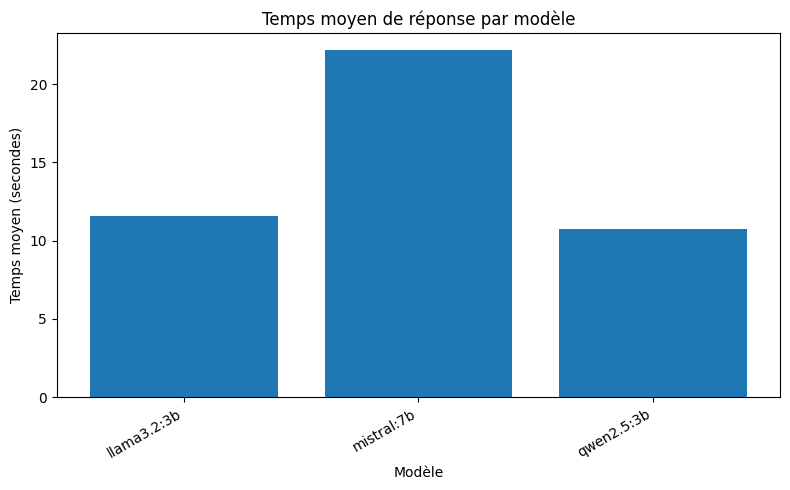

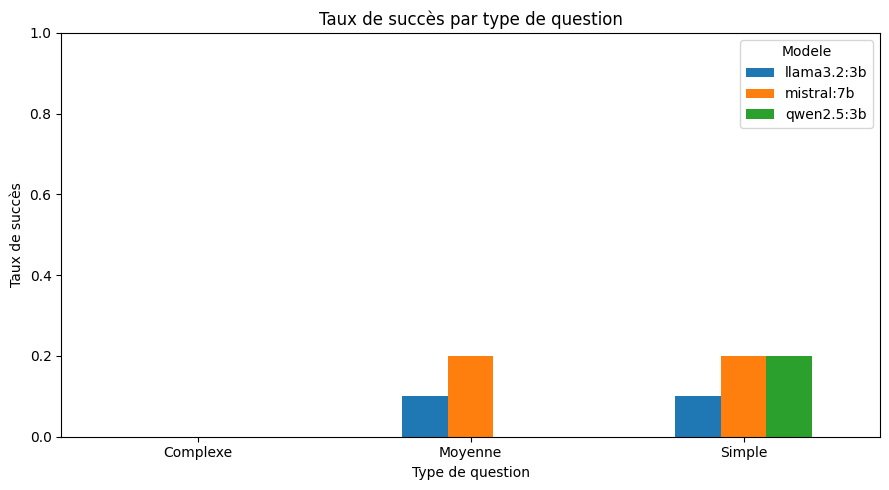

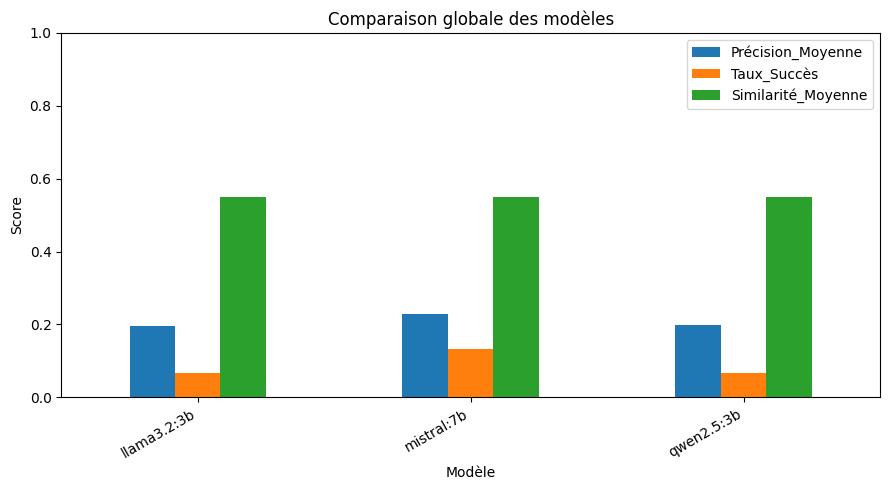

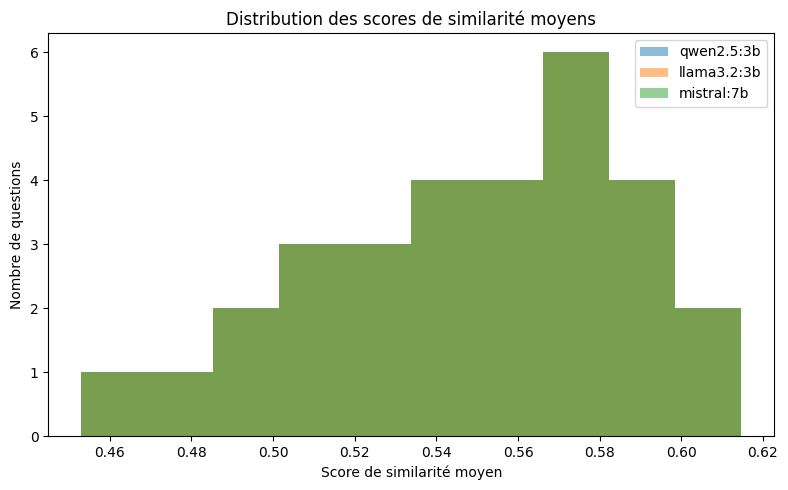

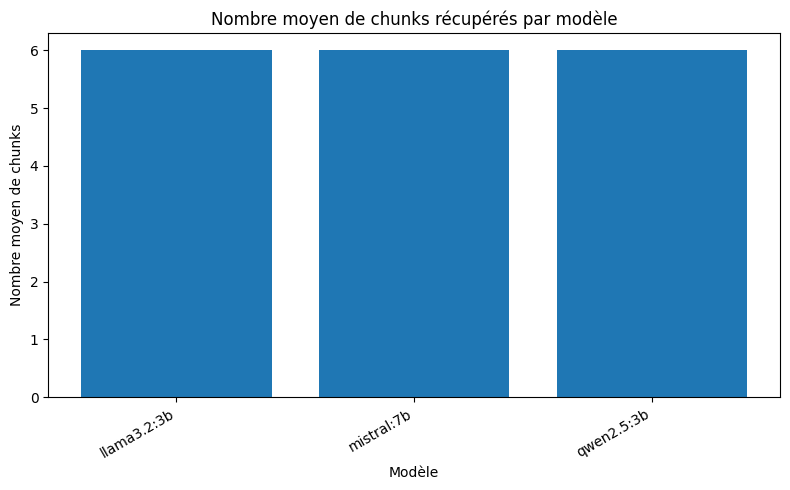

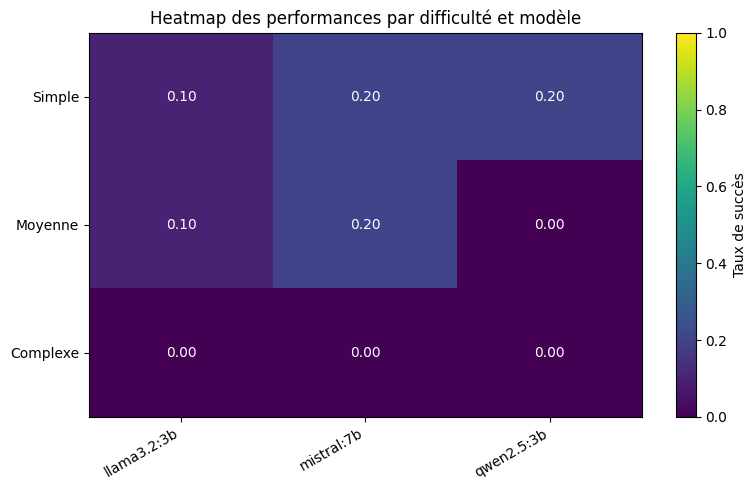

Graphiques sauvegardés dans : /home/ibrahim/Bureau/Projets_de_Stage/results/plots


In [14]:
def save_current_plot(filename: str) -> Path:
    """Sauvegarde la figure matplotlib courante dans results/plots/."""
    path = PLOTS_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    return path


# 1. Temps moyen par modèle.
plt.figure(figsize=(8, 5))
plt.bar(summary_by_model["Modele"], summary_by_model["Temps_Moyen_s"])
plt.title("Temps moyen de réponse par modèle")
plt.xlabel("Modèle")
plt.ylabel("Temps moyen (secondes)")
plt.xticks(rotation=30, ha="right")
save_current_plot("temps_moyen_par_modele.png")
plt.show()

# 2. Taux de succès par type de question.
pivot_success_type = summary_by_type.pivot(index="Type_Question", columns="Modele", values="Taux_Succès")
pivot_success_type.plot(kind="bar", figsize=(9, 5))
plt.title("Taux de succès par type de question")
plt.xlabel("Type de question")
plt.ylabel("Taux de succès")
plt.ylim(0, 1)
plt.xticks(rotation=0)
save_current_plot("taux_succes_par_type_question.png")
plt.show()

# 3. Comparaison globale des modèles : précision, succès et similarité.
comparison = summary_by_model.set_index("Modele")[["Précision_Moyenne", "Taux_Succès", "Similarité_Moyenne"]]
comparison.plot(kind="bar", figsize=(9, 5))
plt.title("Comparaison globale des modèles")
plt.xlabel("Modèle")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
save_current_plot("comparaison_modeles.png")
plt.show()

# 4. Distribution des scores de similarité moyens.
plt.figure(figsize=(8, 5))
for model_name in TESTED_MODELS:
    values = results_df.loc[results_df["Modele"] == model_name, "Score_Similarité_Moyen"]
    plt.hist(values, bins=10, alpha=0.5, label=model_name)
plt.title("Distribution des scores de similarité moyens")
plt.xlabel("Score de similarité moyen")
plt.ylabel("Nombre de questions")
plt.legend()
save_current_plot("distribution_scores_similarite.png")
plt.show()

# 5. Nombre moyen de chunks récupérés.
plt.figure(figsize=(8, 5))
plt.bar(summary_by_model["Modele"], summary_by_model["Chunks_Moyens"])
plt.title("Nombre moyen de chunks récupérés par modèle")
plt.xlabel("Modèle")
plt.ylabel("Nombre moyen de chunks")
plt.xticks(rotation=30, ha="right")
save_current_plot("chunks_moyens_par_modele.png")
plt.show()

# 6. Heatmap des performances sans seaborn.
heatmap_data = performance_by_difficulty.pivot(
    index="Type_Question",
    columns="Modele",
    values="Taux_Succès",
).fillna(0)

plt.figure(figsize=(8, 5))
plt.imshow(heatmap_data.values, aspect="auto", cmap="viridis", vmin=0, vmax=1)
plt.colorbar(label="Taux de succès")
plt.xticks(range(len(heatmap_data.columns)), heatmap_data.columns, rotation=30, ha="right")
plt.yticks(range(len(heatmap_data.index)), heatmap_data.index)
plt.title("Heatmap des performances par difficulté et modèle")

for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        plt.text(j, i, f"{heatmap_data.values[i, j]:.2f}", ha="center", va="center", color="white")

save_current_plot("heatmap_performances.png")
plt.show()

print(f"Graphiques sauvegardés dans : {PLOTS_DIR}")

## 11. Analyse des erreurs

In [15]:
failed_questions = results_df[
    (results_df["Succès_Auto"] == 0)
    | (results_df["Réponse_Absente"] == 1)
    | (results_df["Retrieval_Vide"] == 1)
    | (results_df["Statut"] != "ok")
].copy()

# Une hallucination potentielle est approximée ici par : réponse présente, mais score lexical faible.
potential_hallucinations = results_df[
    (results_df["Réponse_Absente"] == 0)
    & (results_df["Score_Auto_F1"] < AUTO_SUCCESS_THRESHOLD)
].copy()

retrieval_issues = results_df[
    (results_df["Retrieval_Vide"] == 1)
    | (results_df["Score_Similarité_Moyen"] == 0)
].copy()

error_analysis_path = RESULTS_DIR / f"analyse_erreurs_{TIMESTAMP}.xlsx"
with pd.ExcelWriter(error_analysis_path, engine="openpyxl") as writer:
    failed_questions.to_excel(writer, sheet_name="questions_echouees", index=False)
    retrieval_issues.to_excel(writer, sheet_name="retrieval_incorrect", index=False)
    potential_hallucinations.to_excel(writer, sheet_name="hallucinations_potentielles", index=False)

print(f"Questions échouées : {len(failed_questions)}")
print(f"Problèmes de retrieval : {len(retrieval_issues)}")
print(f"Hallucinations potentielles : {len(potential_hallucinations)}")
print(f"Analyse des erreurs exportée : {error_analysis_path}")

failed_questions[["ID", "Type_Question", "Modele", "Question", "Réponse_Attendue", "Réponse_Système", "Score_Auto_F1", "Pages_Sources"]].head(20)

Questions échouées : 82
Problèmes de retrieval : 0
Hallucinations potentielles : 82
Analyse des erreurs exportée : /home/ibrahim/Bureau/Projets_de_Stage/results/analyse_erreurs_20260526_232556.xlsx


,ID,Type_Question,Modele,Question,Réponse_Attendue,Réponse_Système,Score_Auto_F1,Pages_Sources
1,2.0,Simple,qwen2.5:3b,Quel est le nom du programme ?,Master Informatique option SIM,Le nom du programme est Master en Informatique...,0.3529,"1, 2, 4"
3,4.0,Simple,qwen2.5:3b,Quel est le montant de la bourse mensuelle ?,1 500 000 VND par mois,Le montant de la bourse mensuelle est de 1.500...,0.4444,"3, 4"
4,5.0,Simple,qwen2.5:3b,Quelle est la durée minimale du stage ?,5 mois,La durée minimale du stage est 5 mois.,0.4000,"2, 3"
5,6.0,Simple,qwen2.5:3b,La soutenance est-elle obligatoire ?,Oui,La soutenance du mémoire n'est pas expliciteme...,0.0000,"2, 3"
6,7.0,Simple,qwen2.5:3b,L’assurance santé est-elle obligatoire ?,Oui,"Oui, l'assurance santé est obligatoire. Les ét...",0.0571,"2, 5"
7,8.0,Simple,qwen2.5:3b,Le plagiat est-il autorisé ?,Non,Le plagiat dans tous les travaux académiques n...,0.0000,"1, 2, 3"
8,9.0,Simple,qwen2.5:3b,Les examens sont-ils surveillés ?,Oui,Les examens sont surveillés par le personnel d...,0.0000,"1, 2, 3, 4"
9,10.0,Simple,qwen2.5:3b,Les absences doivent-elles être justifiées ?,Oui,"Oui, les absences doivent généralement être ju...",0.1667,"2, 4"
10,11.0,Moyenne,qwen2.5:3b,Que se passe-t-il si un étudiant dépasse 20 % ...,Il doit reprendre le module,"Si l'étudiant dépasse 20% d'absences, il doit ...",0.2308,"2, 3, 4"
11,12.0,Moyenne,qwen2.5:3b,Quand faut-il chercher un stage ?,Dès le début du Master 2,"Au début de Master 2, la Partie B doit cherche...",0.2308,"2, 3, 4"


## 12. Commentaires académiques automatiques

In [16]:
comments = []

if not summary_by_model.empty:
    fastest = summary_by_model.sort_values("Temps_Moyen_s").iloc[0]
    best_success = summary_by_model.sort_values("Taux_Succès", ascending=False).iloc[0]
    best_precision = summary_by_model.sort_values("Précision_Moyenne", ascending=False).iloc[0]

    comments.append(
        f"Le modèle {fastest['Modele']} présente le meilleur temps moyen de réponse "
        f"({fastest['Temps_Moyen_s']:.2f} s)."
    )
    comments.append(
        f"Le modèle {best_success['Modele']} obtient le meilleur taux de succès automatique "
        f"({best_success['Taux_Succès']:.2%})."
    )
    comments.append(
        f"Le modèle {best_precision['Modele']} obtient la meilleure précision moyenne automatique "
        f"({best_precision['Précision_Moyenne']:.3f})."
    )

if "Complexe" in results_df["Type_Question"].astype(str).unique():
    simple_success = results_df.loc[results_df["Type_Question"].astype(str) == "Simple", "Succès_Auto"].mean()
    complex_success = results_df.loc[results_df["Type_Question"].astype(str) == "Complexe", "Succès_Auto"].mean()
    if pd.notna(simple_success) and pd.notna(complex_success) and complex_success < simple_success:
        comments.append(
            "Les questions complexes montrent une baisse de performance par rapport aux questions simples, "
            "ce qui indique une sensibilité du système à la formulation et au raisonnement multi-étapes."
        )

fallback_rate = results_df["Fallback"].mean() if len(results_df) else 0
if fallback_rate > 0:
    comments.append(
        f"Le système retourne une réponse d'absence d'information dans {fallback_rate:.2%} des cas, "
        "ce qui peut provenir d'un contexte récupéré insuffisant ou d'une formulation trop stricte du prompt."
    )

retrieval_empty_rate = results_df["Retrieval_Vide"].mean() if len(results_df) else 0
if retrieval_empty_rate > 0:
    comments.append(
        f"Le retrieval est vide dans {retrieval_empty_rate:.2%} des tests. "
        "Une amélioration possible consiste à ajuster top_k, max_distance ou la stratégie de découpage des documents."
    )

comments_df = pd.DataFrame({"Commentaires_Académiques": comments})
comments_path = RESULTS_DIR / f"commentaires_academiques_{TIMESTAMP}.txt"
comments_path.write_text("\n".join(f"- {comment}" for comment in comments), encoding="utf-8")

for comment in comments:
    print("-", comment)

print(f"Commentaires sauvegardés : {comments_path}")

- Le modèle qwen2.5:3b présente le meilleur temps moyen de réponse (10.74 s).
- Le modèle mistral:7b obtient le meilleur taux de succès automatique (13.33%).
- Le modèle mistral:7b obtient la meilleure précision moyenne automatique (0.229).
- Les questions complexes montrent une baisse de performance par rapport aux questions simples, ce qui indique une sensibilité du système à la formulation et au raisonnement multi-étapes.
Commentaires sauvegardés : /home/ibrahim/Bureau/Projets_de_Stage/results/commentaires_academiques_20260526_232556.txt


## 13. Conclusion

Ce notebook fournit une base expérimentale reproductible pour comparer plusieurs LLM dans un système RAG académique. Les résultats exportés peuvent être utilisés dans le mémoire pour présenter :

- la performance globale par modèle ;
- la performance selon la difficulté des questions ;
- le coût temporel des réponses ;
- la qualité du retrieval ;
- les erreurs fréquentes du système ;
- les limites entre évaluation automatique et évaluation humaine.

Les colonnes `Pertinence`, `Exactitude`, `Fidélité` et `Clarté` doivent être complétées manuellement pour produire une évaluation semi-automatique plus rigoureuse.